# 02 — Exploratory Data Analysis

**Owner:** Seneviratne's lane — distributions, outliers, correlations, class-conditional comparisons, `grip_lost` analysis.

**Purpose:** see how each sensor family behaves overall and between normal and stop rows, decide how to treat outliers, and note which signals separate the classes (and which only look as if they do).

**Output:** figures `fig02_*` (distributions, boxplots, correlation heatmap) and four logged entries: retain and robustly scale the outliers, `grip_lost` is not a driver of stops, speed drops are a consequence of a stop, and which features separate the classes.

**Viva questions to be ready for:** Are outliers errors or signal? Which features separate the classes?

Every important choice has a decision-log cell (what we decided, the evidence, the alternative considered, why it was rejected).

In [1]:
import sys
from pathlib import Path

# Jupyter's kernel CWD is notebooks/, so add the repo root to sys.path
# before importing anything from src/.
sys.path.append(str(Path.cwd().parent))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import RANDOM_STATE, FIGURES_DIR
from src.pipeline import load_data

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
df = load_data()
df.shape

(7409, 24)

## Sensor families

Group columns by family for reuse below (Current_*, Temperature_*, Speed_J*, Tool_current).

In [4]:
current_cols = [c for c in df.columns if c.startswith("Current_")]
temperature_cols = [c for c in df.columns if c.startswith("Temperature_")]
speed_cols = [c for c in df.columns if c.startswith("Speed_")]
tool_cols = ["Tool_current"]

current_cols, temperature_cols, speed_cols, tool_cols

(['Current_J0',
  'Current_J1',
  'Current_J2',
  'Current_J3',
  'Current_J4',
  'Current_J5'],
 ['Temperature_T0',
  'Temperature_J1',
  'Temperature_J2',
  'Temperature_J3',
  'Temperature_J4',
  'Temperature_J5'],
 ['Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3', 'Speed_J4', 'Speed_J5'],
 ['Tool_current'])

## Distributions by sensor family and class

Histogram and KDE plots per feature split by `Robot_ProtectiveStop` (0 vs 1) and grouped by sensor family. Figures are saved to `FIGURES_DIR / "fig02_distributions_<family>.png"`.

Saved: reports/figures/fig02_distributions_current.png


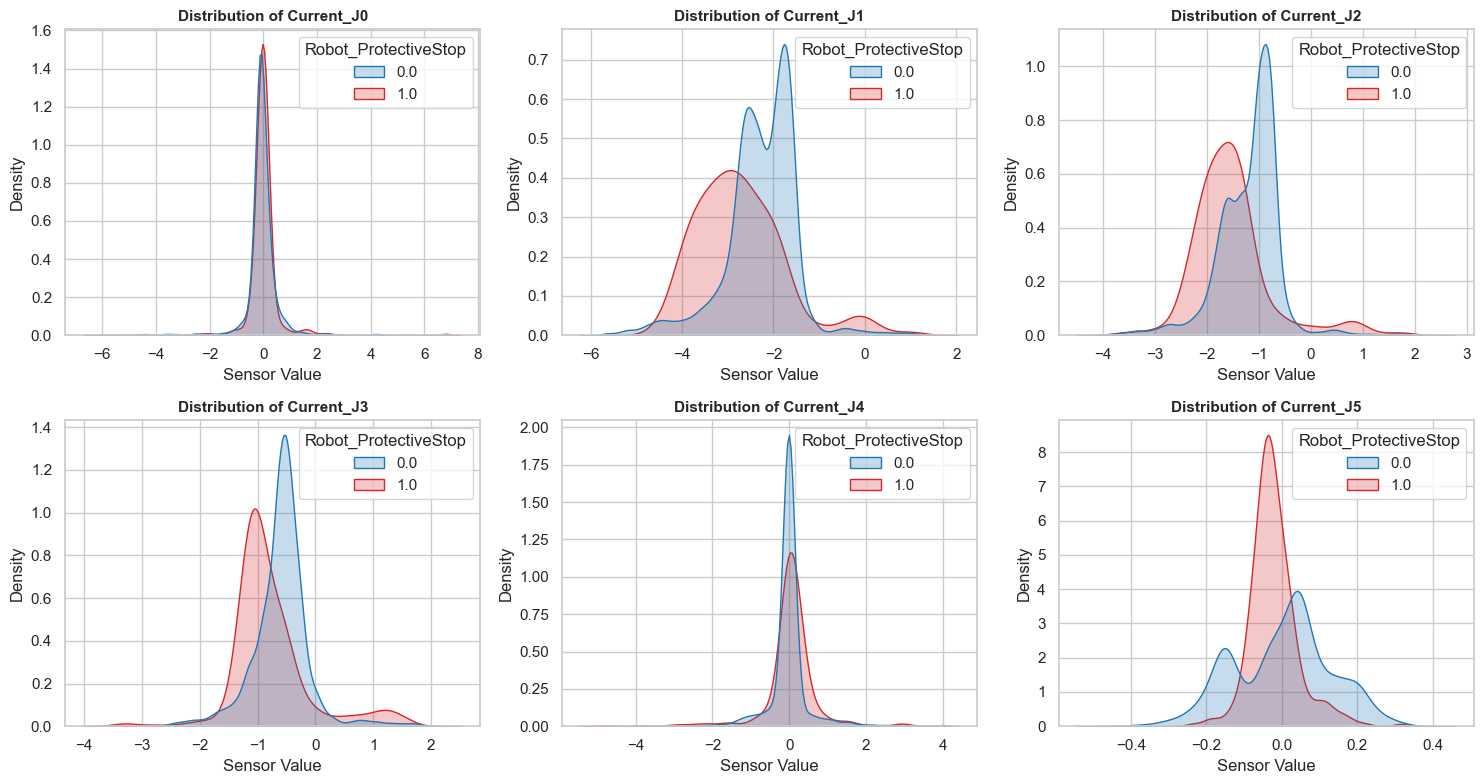

Saved: reports/figures/fig02_distributions_temperature.png


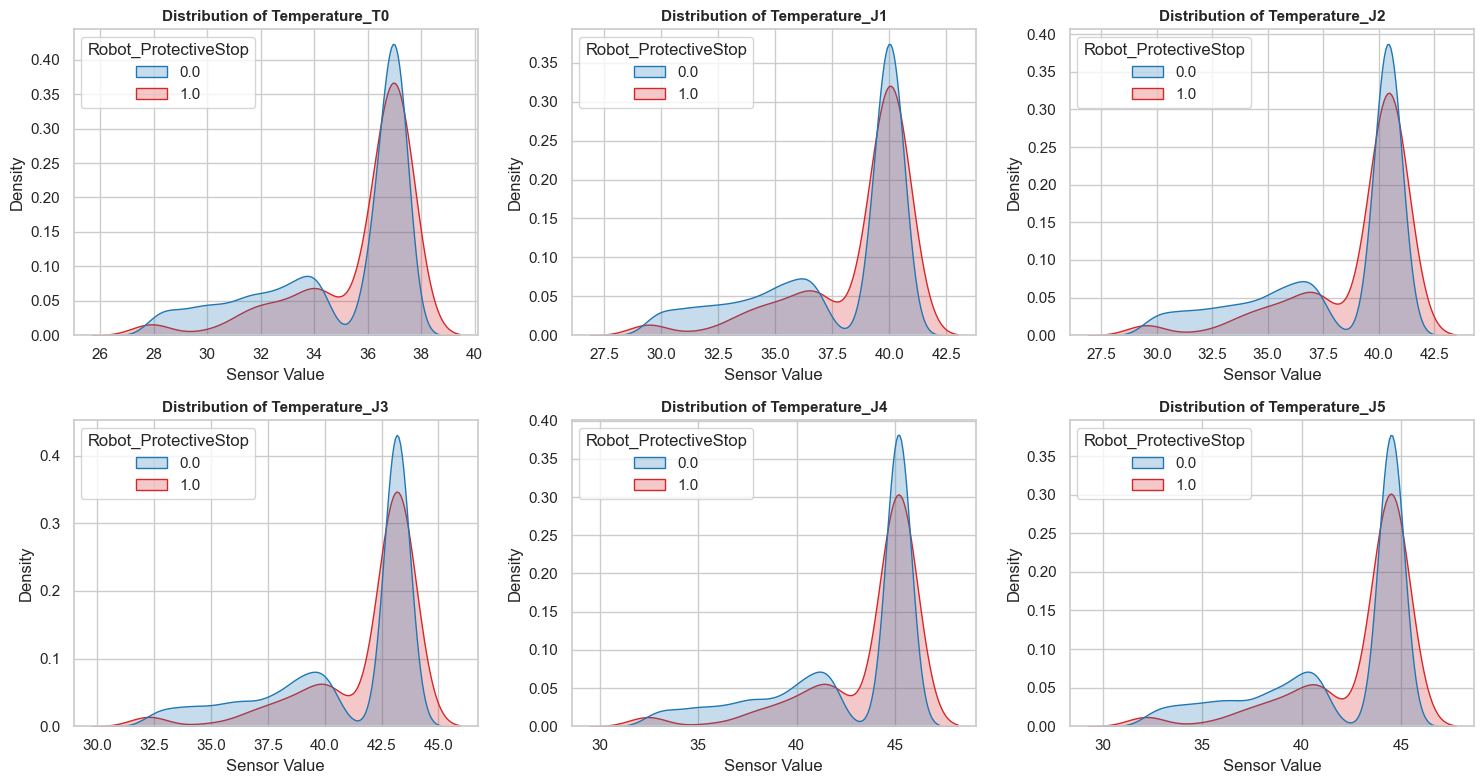

Saved: reports/figures/fig02_distributions_speed.png


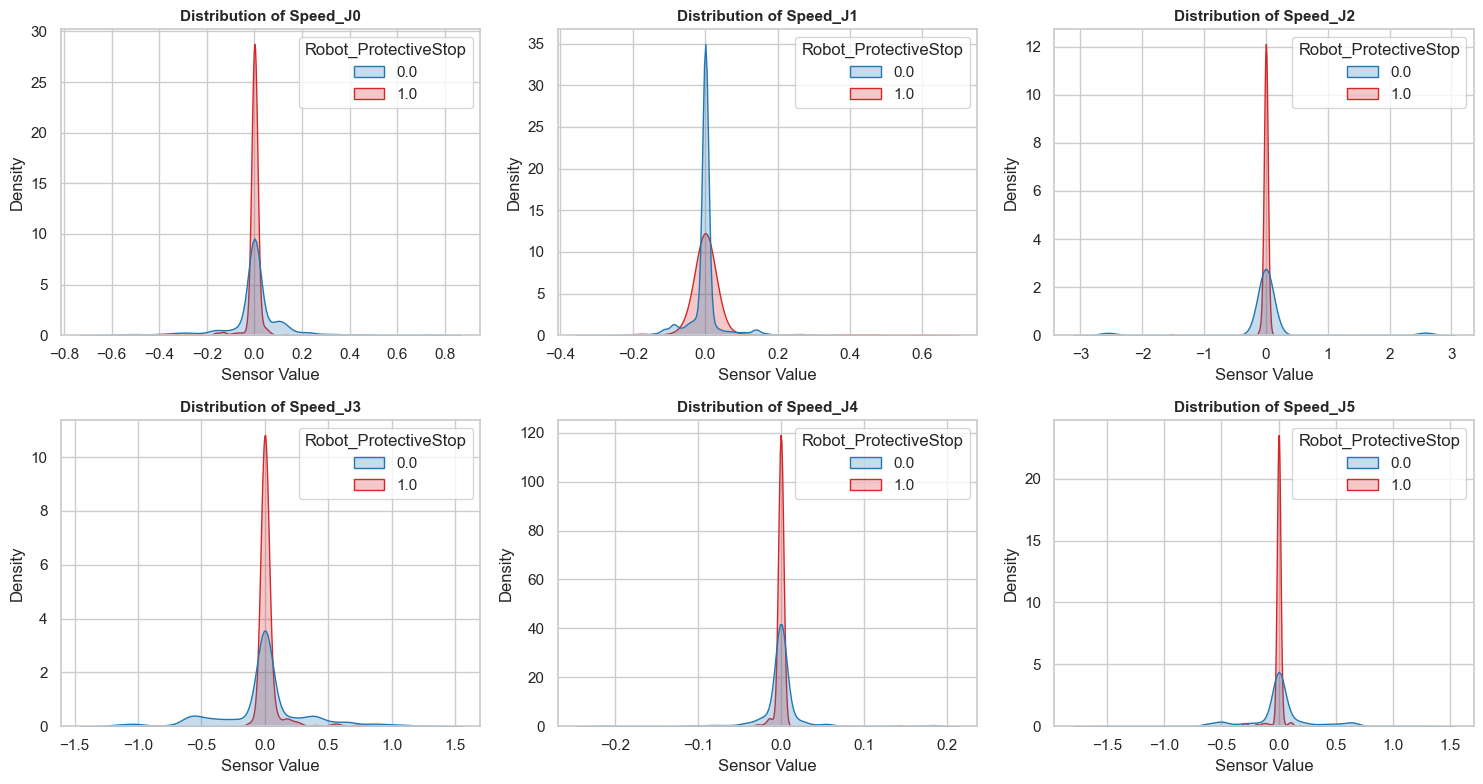

Saved: reports/figures/fig02_distributions_tool.png


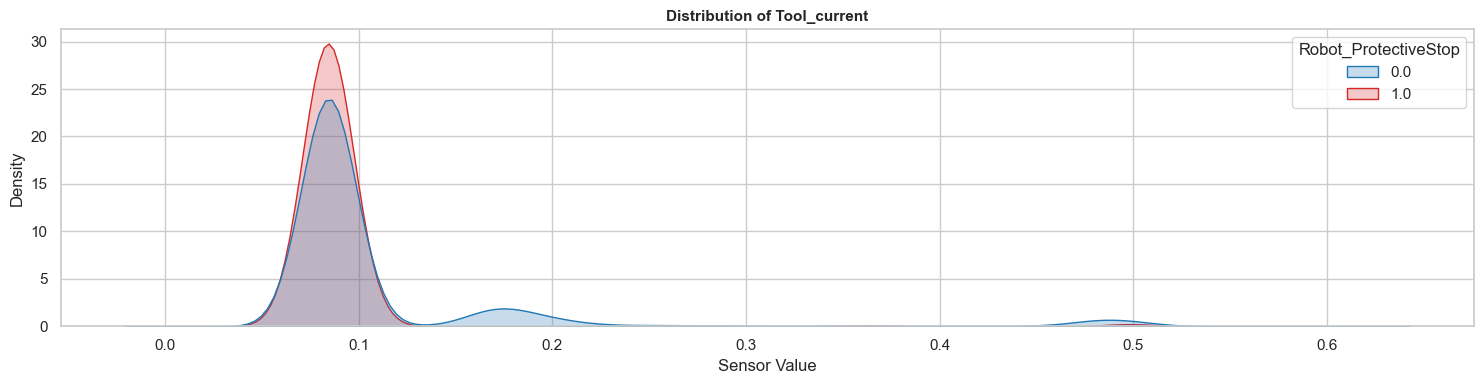

In [5]:
# Distributions per sensor family split by class
families = {
    "current": current_cols,
    "temperature": temperature_cols,
    "speed": speed_cols,
    "tool": tool_cols
}

for family_name, cols in families.items():
    n_cols = len(cols)
    fig, axes = plt.subplots(nrows=(n_cols + 2) // 3, ncols=min(3, n_cols), figsize=(15, 4 * ((n_cols + 2) // 3)))
    if n_cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for idx, col in enumerate(cols):
        sns.kdeplot(
            data=df,
            x=col,
            hue="Robot_ProtectiveStop",
            common_norm=False,
            fill=True,
            palette={0: "#1f77b4", 1: "#d62728"},
            ax=axes[idx]
        )
        axes[idx].set_title(f"Distribution of {col}", fontsize=11, fontweight="bold")
        axes[idx].set_xlabel("Sensor Value")
    
    for idx in range(n_cols, len(axes)):
        fig.delaxes(axes[idx])
        
    plt.tight_layout()
    fig_path = FIGURES_DIR / f"fig02_distributions_{family_name}.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    print(f"Saved: reports/figures/{fig_path.name}")
    plt.show()

## Boxplots + outlier counts

Boxplot per feature; count IQR-based outliers per feature (below Q1 - 1.5*IQR or above Q3 + 1.5*IQR). Decide per-feature whether outliers look like sensor errors or genuine extreme readings (part of the viva answer).

In [6]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

numeric_cols = current_cols + temperature_cols + speed_cols + tool_cols
outlier_summary = pd.DataFrame({
    "outlier_count": [iqr_outlier_count(df[c]) for c in numeric_cols],
    "outlier_pct": [round(100 * iqr_outlier_count(df[c]) / len(df), 2) for c in numeric_cols]
}, index=numeric_cols)

outlier_summary.sort_values(by="outlier_count", ascending=False)

,outlier_count,outlier_pct
Speed_J3,3432,46.32
Speed_J0,3215,43.39
Speed_J4,3172,42.81
Speed_J5,3164,42.70
Speed_J1,2962,39.98
Speed_J2,2715,36.64
Current_J4,1313,17.72
Tool_current,1043,14.08
Current_J0,967,13.05
Current_J3,579,7.81


### Are the outliers errors? Value ranges, outliers by class, and the speed columns

Three checks behind the outlier decision: (1) are any values physically impossible (value ranges)? (2) are outliers concentrated in stop rows (share of IQR outliers per class, using the same 1.5×IQR rule on the labelled rows)? (3) why do the speed columns show 37–46% "outliers" (how much of each speed column sits at zero)?

In [7]:
labelled = df[df["Robot_ProtectiveStop"].notna()]


def iqr_bounds(series):
    q1, q3 = series.quantile([0.25, 0.75])
    return q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)


rows = {}
for col in current_cols + tool_cols:
    lo, hi = iqr_bounds(labelled[col])
    is_out = (labelled[col] < lo) | (labelled[col] > hi)
    rows[col] = {
        "outliers, normal rows (%)": 100 * is_out[labelled["Robot_ProtectiveStop"] == 0].mean(),
        "outliers, stop rows (%)": 100 * is_out[labelled["Robot_ProtectiveStop"] == 1].mean(),
        "min": labelled[col].min(), "max": labelled[col].max(),
    }
display(pd.DataFrame(rows).T.round(2))

print(f"Temperature range: {labelled[temperature_cols].min().min():.1f} to {labelled[temperature_cols].max().max():.1f} C")
print("\nShare of readings with |speed| < 0.001 rad/s (idle joint):")
print((labelled[speed_cols].abs() < 1e-3).mean().round(2).to_string())

,"outliers, normal rows (%)","outliers, stop rows (%)",min,max
Current_J0,13.30,8.27,-6.25,6.81
Current_J1,5.41,10.43,-5.81,1.08
Current_J2,4.30,6.83,-4.17,2.46
Current_J3,7.72,11.87,-3.33,2.27
Current_J4,17.75,20.50,-4.74,4.09
Current_J5,0.45,0.00,-0.47,0.39
Tool_current,14.68,1.44,0.02,0.60


Temperature range: 27.8 to 45.4 C

Share of readings with |speed| < 0.001 rad/s (idle joint):
Speed_J0    0.51
Speed_J1    0.53
Speed_J2    0.49
Speed_J3    0.46
Speed_J4    0.61
Speed_J5    0.47


Saved: reports/figures/fig02_boxplots.png


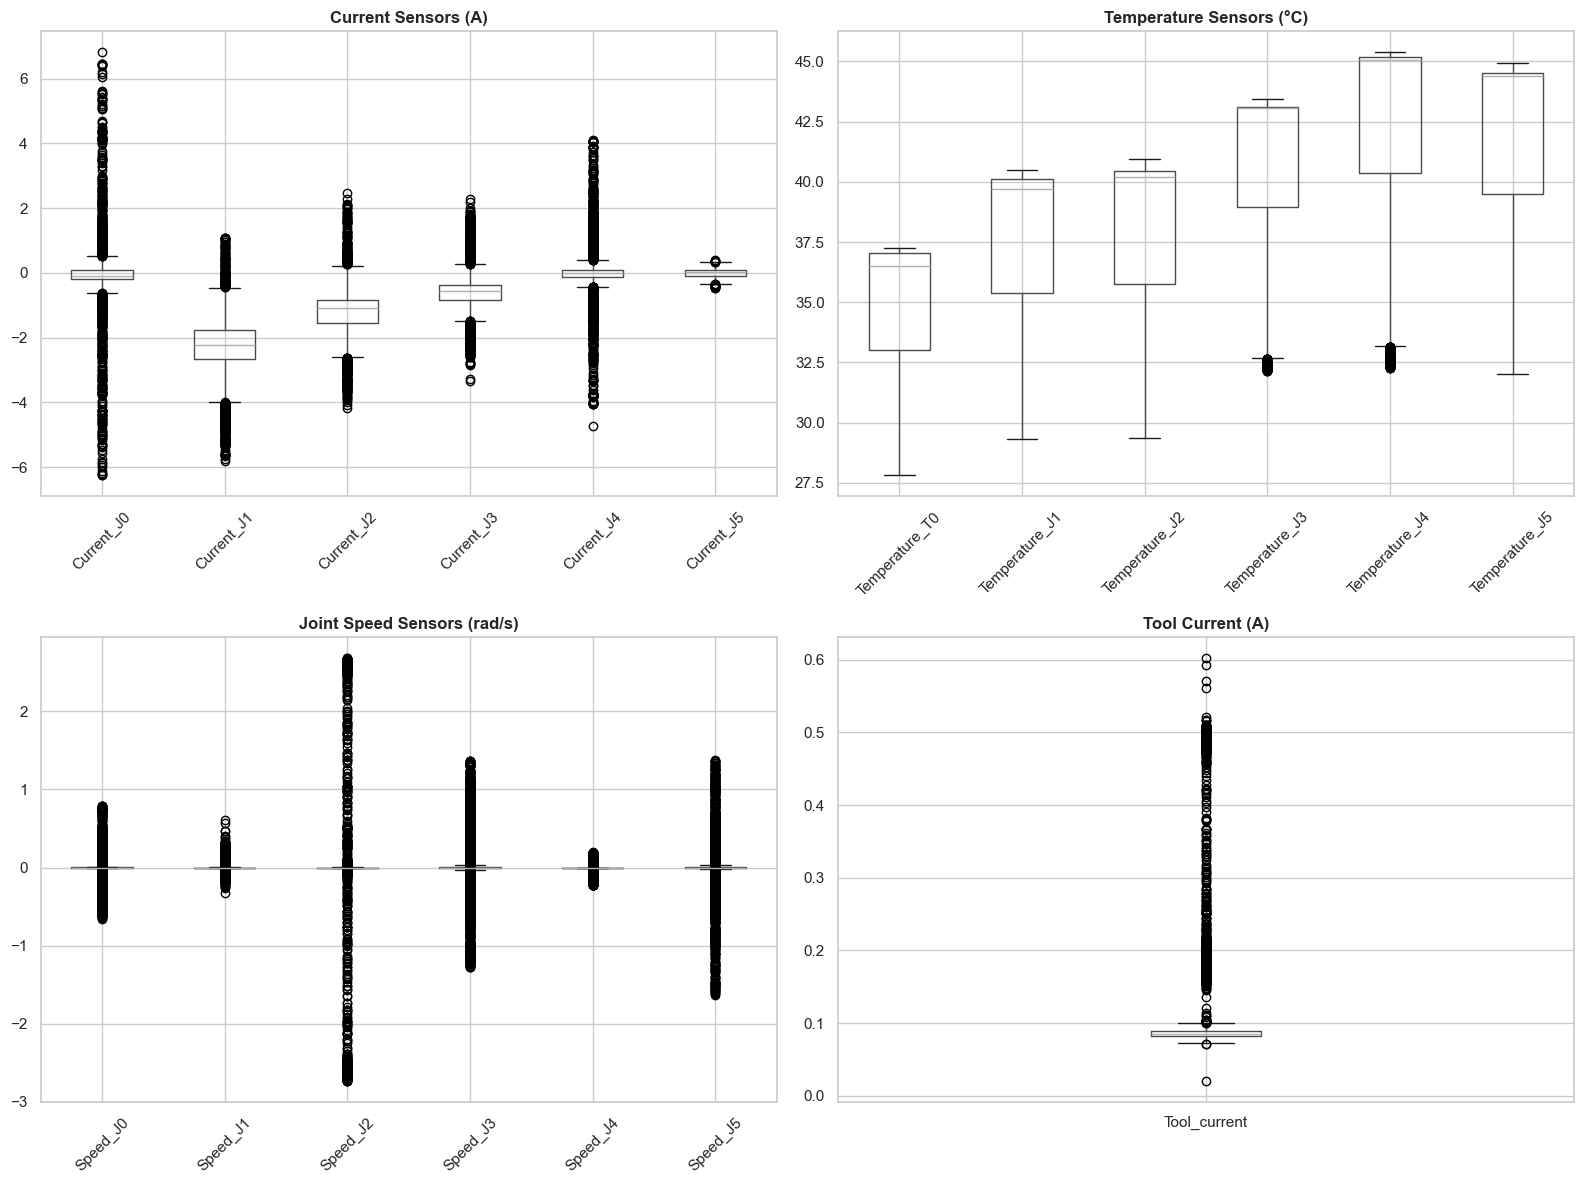

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Current
df.boxplot(column=current_cols, ax=axes[0, 0], rot=45)
axes[0, 0].set_title("Current Sensors (A)", fontweight="bold")

# Temperature
df.boxplot(column=temperature_cols, ax=axes[0, 1], rot=45)
axes[0, 1].set_title("Temperature Sensors (°C)", fontweight="bold")

# Speed
df.boxplot(column=speed_cols, ax=axes[1, 0], rot=45)
axes[1, 0].set_title("Joint Speed Sensors (rad/s)", fontweight="bold")

# Tool current
df.boxplot(column=tool_cols, ax=axes[1, 1])
axes[1, 1].set_title("Tool Current (A)", fontweight="bold")

plt.tight_layout()
fig_path = FIGURES_DIR / "fig02_boxplots.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved: reports/figures/{fig_path.name}")
plt.show()

## Correlation heatmap

Correlation matrix across all sensor features (+ target). Saved to `FIGURES_DIR / "fig02_correlation.png"`.

Saved: reports/figures/fig02_correlation.png


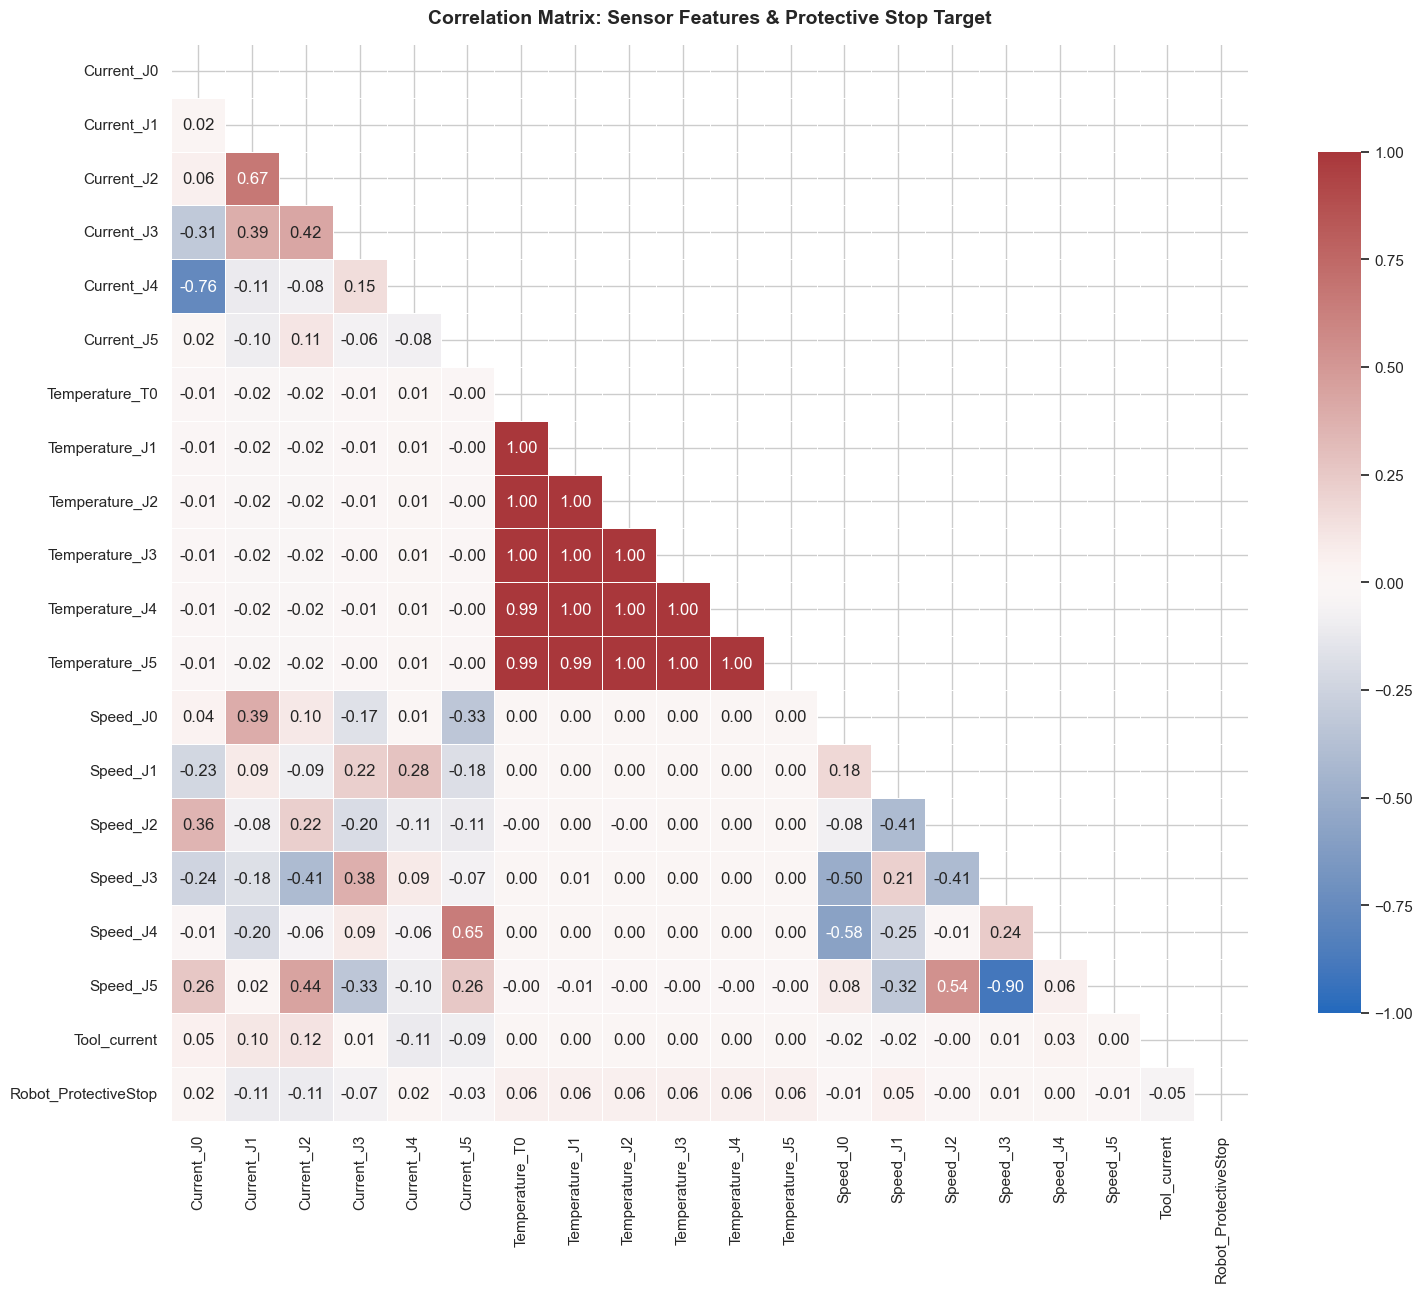

In [9]:
corr_cols = numeric_cols + ["Robot_ProtectiveStop"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix: Sensor Features & Protective Stop Target", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
fig_path = FIGURES_DIR / "fig02_correlation.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved: reports/figures/{fig_path.name}")
plt.show()

In [10]:
temp_corr = df[temperature_cols].corr()
off_diagonal = temp_corr.where(~np.eye(len(temperature_cols), dtype=bool))
print(f"Pairwise correlation between the {len(temperature_cols)} temperature columns: "
      f"min {off_diagonal.min().min():.3f}, max {off_diagonal.max().max():.3f}")

Pairwise correlation between the 6 temperature columns: min 0.993, max 1.000


## grip_lost cross-tab

`pd.crosstab(df["grip_lost"], df["Robot_ProtectiveStop"])`. Plan expects grip_lost overlaps a stop on only 3 rows out of 243 grip-loss rows — confirm it reads as a weak, largely separate signal rather than a strong predictor.

In [11]:
ct = pd.crosstab(
    df["grip_lost"],
    df["Robot_ProtectiveStop"],
    margins=True,
    margins_name="Total"
)
ct_norm = pd.crosstab(
    df["grip_lost"],
    df["Robot_ProtectiveStop"],
    normalize="index"
) * 100

print("Cross-tabulation (Counts):")
display(ct)
print("\nCross-tabulation (Row Percentages %):")
display(ct_norm.round(2))

Cross-tabulation (Counts):


Robot_ProtectiveStop,0.0,1.0,Total
grip_lost,,,
False,6837,275,7112
True,240,3,243
Total,7077,278,7355



Cross-tabulation (Row Percentages %):


Robot_ProtectiveStop,0.0,1.0
grip_lost,,
False,96.13,3.87
True,98.77,1.23


## Class-conditional comparisons

For each sensor family, compare summary stats (median/mean) between stop rows and normal rows — which features separate the classes most clearly? This feeds directly into notebook 03's leakage discussion, so cross-check findings with that notebook (e.g. speed features separating the classes is the leakage signal, not necessarily a usable feature).

In [12]:
medians_by_class = df.groupby("Robot_ProtectiveStop")[numeric_cols].median().T
medians_by_class.columns = ["Normal (0) Median", "Stop (1) Median"]
medians_by_class["Difference"] = medians_by_class["Stop (1) Median"] - medians_by_class["Normal (0) Median"]
medians_by_class["Ratio (Stop/Normal)"] = (medians_by_class["Stop (1) Median"] / medians_by_class["Normal (0) Median"]).round(3)
medians_by_class.sort_values(by="Difference", ascending=False)

,Normal (0) Median,Stop (1) Median,Difference,Ratio (Stop/Normal)
Temperature_T0,36.500000,36.937500,0.437500,1.012
Temperature_J1,39.687500,39.937500,0.250000,1.006
Temperature_J2,40.187500,40.312500,0.125000,1.003
Temperature_J3,43.062500,43.125000,0.062500,1.001
Temperature_J5,44.375000,44.437500,0.062500,1.001
Temperature_J4,45.062500,45.125000,0.062500,1.001
Current_J0,-0.083452,-0.020977,0.062474,0.251
Current_J4,-0.014018,0.018759,0.032777,-1.338
Speed_J0,0.000000,0.000000,0.000000,NaN
Speed_J1,0.000000,0.000000,0.000000,NaN


The per-joint speed medians are 0 for both classes because each speed column is at (almost) zero for about half of all rows. The class difference is visible in the *total* speed across the six joints, so we compare that directly.

In [13]:
total_speed = labelled[speed_cols].abs().sum(axis=1)
print("Median total |speed| (sum over the 6 joints), rad/s:")
print(total_speed.groupby(labelled["Robot_ProtectiveStop"]).median().round(4).to_string())
print("\nShare of rows with total |speed| < 0.01:")
print((total_speed < 0.01).groupby(labelled["Robot_ProtectiveStop"]).mean().round(3).to_string())

Median total |speed| (sum over the 6 joints), rad/s:
Robot_ProtectiveStop
0.0    0.0562
1.0    0.0020

Share of rows with total |speed| < 0.01:
Robot_ProtectiveStop
0.0    0.456
1.0    0.637


## Decision log

### Decision 1: Outlier treatment — retain, and scale robustly
- **Decision:** Keep every value, including IQR outliers; do not clip or drop them. Limit their influence with `RobustScaler` (notebook 04) instead.
- **Evidence:**
  - IQR outlier shares are large for some columns: currents from 0.4% (Current_J5) to 17.7% (Current_J4), Tool_current 14.1%, temperatures at most 1.9%, and speeds 37–46% (first table above).
  - The speed figures are an artefact of the rule, not a sign of bad data: about half of all speed readings are at or near zero (idle joint), so the IQR collapses and any movement counts as an "outlier".
  - No value is physically impossible: currents −6.25 to 6.81 A, temperatures 27.8–45.4 °C, tool current 0.02–0.60 A.
  - Outliers are not simply a stop indicator. Stop rows have more outliers than normal rows for Current_J1 (10.4% vs 5.4%) and Current_J3 (11.9% vs 7.7%), but fewer for Current_J0 (8.3% vs 13.3%) and Tool_current (1.4% vs 14.7%).
- **Answer to "errors or signal?":** they are genuine readings from a moving robot, not sensor errors. For some joints they are more common at stops, so they can carry signal, but they are not a reliable stop indicator on their own.
- **Alternative considered:** Winsorizing (clipping at the 1st/99th percentile) or removing IQR outliers.
- **Why rejected:** There is no evidence they are errors, and clipping would throw away the large-magnitude readings the classifiers can use. `RobustScaler` (median and IQR) stops them dominating the scaling without discarding them.

### Decision 2: Feature role of `grip_lost`
- **Decision:** Do not rely on `grip_lost` as a predictor of protective stops.
- **Evidence:** Of 243 grip-loss rows only 3 coincide with a protective stop; the stop rate is 1.23% when grip is lost against 3.87% when it is not. There is no sign in this data that grip loss drives stops. (Notebook 07 later confirms it adds nothing to the model.)
- **Alternative considered:** Using `grip_lost` as a strong predictive rule/feature.
- **Why rejected:** It shows no positive association with `Robot_ProtectiveStop`.

### Decision 3: Speed drops at a stop, so treat speed as a consequence, not a predictor
- **Decision:** Treat the drop in joint speed at stop rows as a consequence of the stop, and keep speed out of the predictors (formalised in notebook 03).
- **Evidence:** Each speed column is at or near zero for about half of all rows, so the per-joint medians are 0 for both classes (class-conditional table). The class difference shows in the total: median total |speed| is 0.056 rad/s for normal rows and 0.002 for stop rows. Near-zero speed is common even in normal operation (45.6% of normal rows against 63.7% of stop rows), so speed is not a clean separator either.
- **Alternative considered:** Using instantaneous speed as a predictor.
- **Why rejected:** A stopped robot has zero speed by definition, so same-row speed describes the outcome rather than predicting it. Leakage is examined around the stop episodes in notebook 03.

### Observation 4: Which features separate the classes?
- **Evidence (class-conditional medians):** Current_J1, J2 and J3 are more negative at stop rows (−2.82 vs −2.22, −1.61 vs −1.06 and −0.99 vs −0.56 A); `total_joint_current` is higher (notebook 03: 5.99 vs 4.31); Tool_current does not differ. Temperatures are 0.06–0.44 °C higher at stop rows, but the six temperature columns move together (pairwise correlation above 0.99) and track the time of day, so that difference mostly reflects when stops happened (notebook 07, section 4).
- **Implication:** the joint currents are the signals that separate the classes. Temperature, `grip_lost` and speed are not usable evidence of an approaching stop.